In [ ]:
import pandas as pd #biblioteca que permite generar dataset o dataframe
import numpy as np #biblioteca para calculo, arreglos, matrices, elabora datasets a traves de listas
import matplotlib.pyplot as plt #herramientas graficas
import seaborn as sns
#INGRESAMOS LA DIRECCION DEL ARCHIVO
entrenamiento = pd.read_csv('/content/Datos_abiertos_matriculas_2016_1_2024_1.csv')

In [ ]:
entrenamiento.head(5)

,IDHASH,COLEGIO_DEPA,COLEGIO_PROV,COLEGIO_DIST,ANIO,PERIODO,TIPO_MATRICULA,DOMICILIO_DEPA,DOMICILIO_PROV,DOMICILIO_DIST,...,NACIMIENTO_PAIS,NACIMIENTO_DEPA,NACIMIENTO_PROV,NACIMIENTO_DIST,SEXO,MODALIDAD,METODOLOGIA,FACULTAD,ESPECIALIDAD,CICLO_RELATIVO
0,07E35E858686718757529DDDBEC110B0B39CA2FCC810A6...,LIMA,LIMA METROPOLITANA,LURIGANCHO,2016,1,Regulares,LIMA,LIMA METROPOLITANA,LURIGANCHO,...,Peru,LIMA,LIMA METROPOLITANA,LURIGANCHO,MASCULINO,INGRESO DIRECTO,PRESENCIAL,INGENIERÍA INDUSTRIAL Y DE SISTEMAS,INGENIERÍA INDUSTRIAL,3
1,24DAB8EC1FDFA72428AF843FFABB4901743386A9EBD0A1...,LIMA,LIMA METROPOLITANA,ATE,2016,1,Regulares,LIMA,LIMA METROPOLITANA,ATE,...,Peru,JUNÍN,SATIPO,PANGOA,MASCULINO,DOS PRIMEROS ALUMNOS,PRESENCIAL,"INGENIERÍA ECONÓMICA, ESTADÍSTICA Y CIENCIAS S...",INGENIERÍA ECONÓMICA,2
2,0FD5293AAD1655B7FBF28920796B1C49144F4B7F3BEA24...,LIMA,LIMA METROPOLITANA,VILLA EL SALVADOR,2016,1,Regulares,LIMA,LIMA METROPOLITANA,VILLA MARIA DEL TRIUNFO,...,Peru,LIMA,LIMA METROPOLITANA,JESUS MARIA,MASCULINO,ORDINARIO,PRESENCIAL,INGENIERÍA ELÉCTRICA Y ELECTRÓNICA,INGENIERÍA ELECTRÓNICA,2
3,5B07CA8222FAB9610D2B3C0D3789CAF1103479F47ACA8E...,ÁNCASH,CARHUAZ,CARHUAZ,2016,1,Regulares,ÁNCASH,CARHUAZ,CARHUAZ,...,Peru,ÁNCASH,HUARAZ,INDEPENDENCIA,MASCULINO,INGRESO DIRECTO,PRESENCIAL,"INGENIERÍA DE PETRÓLEO, GAS NATURAL Y PETROQUÍ...",INGENIERÍA PETROQUÍMICA,2
4,FF657E45CD5AE985DCDF4E3C7B5CCA17F90056F075473C...,LIMA,LIMA METROPOLITANA,CARABAYLLO,2016,1,Regulares,AMAZONAS,NaN,NaN,...,Peru,LIMA,LIMA METROPOLITANA,SAN MARTIN DE PORRES,MASCULINO,ORDINARIO,PRESENCIAL,INGENIERÍA MECÁNICA,INGENIERÍA MECÁNICA Y ELÉCTRICA,1


In [ ]:
entrenamiento.isnull()

,IDHASH,COLEGIO_DEPA,COLEGIO_PROV,COLEGIO_DIST,ANIO,PERIODO,TIPO_MATRICULA,DOMICILIO_DEPA,DOMICILIO_PROV,DOMICILIO_DIST,...,NACIMIENTO_PAIS,NACIMIENTO_DEPA,NACIMIENTO_PROV,NACIMIENTO_DIST,SEXO,MODALIDAD,METODOLOGIA,FACULTAD,ESPECIALIDAD,CICLO_RELATIVO
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192384,False,True,True,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
192385,False,True,True,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
192386,False,True,True,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
192387,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


<Axes: >

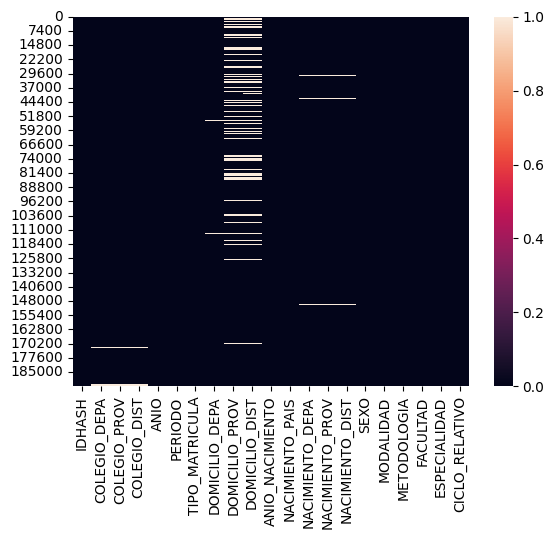

In [ ]:
sns.heatmap(entrenamiento.isnull())

In [ ]:
#Para ser mas exactos mostramos los nulos exactos con un print
def columnas_con_nulos(entrenamiento):
    # Filtramos las columnas con valores nulos
    columnas_nulas = entrenamiento.isnull().sum()

    # Filtramos solo aquellas columnas que tienen al menos un valor nulo
    columnas_nulas = columnas_nulas[columnas_nulas > 0]

    # Retorna las columnas con nulos y la cantidad de nulos por columna
    return columnas_nulas

columnas_nulas = columnas_con_nulos(entrenamiento)
print(columnas_nulas)

COLEGIO_DEPA        3703
COLEGIO_PROV        3848
COLEGIO_DIST        3947
DOMICILIO_DEPA      1491
DOMICILIO_PROV     21622
DOMICILIO_DIST     21866
NACIMIENTO_PAIS      187
NACIMIENTO_DEPA      640
NACIMIENTO_PROV      717
NACIMIENTO_DIST      717
dtype: int64


In [ ]:
#A continuacion vamos a ver la moda de cada una de nuestras columnas en las que se hayaron datos que esten haciendo ruido
cd = entrenamiento['COLEGIO_DEPA'].value_counts().reset_index()
cd.columns = ['DEPARTAMENTO', 'CANTIDAD']
print(cd)

     DEPARTAMENTO  CANTIDAD
0            LIMA    145492
1           JUNÍN      9582
2          CALLAO      7421
3          ÁNCASH      5042
4        AYACUCHO      2244
5         HUÁNUCO      2075
6             ICA      1979
7      LAMBAYEQUE      1921
8        APURÍMAC      1561
9       CAJAMARCA      1496
10       AMAZONAS      1431
11           PUNO      1373
12   HUANCAVELICA      1369
13          PASCO      1109
14    LA LIBERTAD      1064
15          CUSCO       885
16     SAN MARTÍN       629
17       AREQUIPA       450
18          PIURA       447
19         LORETO       355
20          TACNA       247
21        UCAYALI       182
22         TUMBES       158
23       MOQUEGUA       106
24  MADRE DE DIOS        68


In [ ]:
cp = entrenamiento['COLEGIO_PROV'].value_counts().reset_index()
cp.columns = ['PROVINCIA', 'CANTIDAD']
print(cp)

              PROVINCIA  CANTIDAD
0    LIMA METROPOLITANA    139986
1                CALLAO      7410
2              HUANCAYO      5322
3                HUARAZ      2024
4              CHICLAYO      1608
..                  ...       ...
171                LIMA         2
172            CANGALLO         2
173          PADRE ABAD         2
174             CUTERVO         1
175            CASTILLA         1

[176 rows x 2 columns]


In [ ]:
cd = entrenamiento['COLEGIO_DIST'].value_counts().reset_index()
cd.columns = ['DISTRITO', 'CANTIDAD']
print(cd)

                   DISTRITO  CANTIDAD
0    SAN JUAN DE LURIGANCHO     16954
1      SAN MARTIN DE PORRES     12936
2                     COMAS     12285
3                LOS OLIVOS     11871
4                       ATE      9116
..                      ...       ...
623                CHAPARRA         1
624                SOCABAYA         1
625                   ATICO         1
626                  ARENAL         1
627               ORCOPAMPA         1

[628 rows x 2 columns]


In [ ]:
dp = entrenamiento['DOMICILIO_DEPA'].value_counts().reset_index()
dp.columns = ['DEPARTAMENTO', 'CANTIDAD']
print(dp)

     DEPARTAMENTO  CANTIDAD
0            LIMA    151390
1        AMAZONAS     23349
2          CALLAO      7351
3           JUNÍN      2286
4          ÁNCASH      1160
5      LAMBAYEQUE       915
6             ICA       706
7        AYACUCHO       627
8         HUÁNUCO       540
9       CAJAMARCA       387
10           PUNO       347
11       APURÍMAC       327
12   HUANCAVELICA       311
13    LA LIBERTAD       259
14          PASCO       218
15          CUSCO       209
16     SAN MARTÍN       166
17       AREQUIPA       120
18         LORETO        67
19         TUMBES        40
20          TACNA        36
21        UCAYALI        27
22          PIURA        26
23       MOQUEGUA        19
24  MADRE DE DIOS        15


In [ ]:
dpr = entrenamiento['DOMICILIO_PROV'].value_counts().reset_index()
dpr.columns = ['PROVINCIA', 'CANTIDAD']
print(dpr)

              PROVINCIA  CANTIDAD
0    LIMA METROPOLITANA    148317
1                CALLAO      7351
2              AMAZONAS      3076
3              HUANCAYO      1357
4            HUAROCHIRÍ       875
..                  ...       ...
130           UTCUBAMBA         1
131             CUTERVO         1
132            CHUCUITO         1
133            CARAVELÍ         1
134               LAMAS         1

[135 rows x 2 columns]


In [ ]:
dd = entrenamiento['DOMICILIO_DIST'].value_counts().reset_index()
dd.columns = ['DISTRITO', 'CANTIDAD']
print(dd)

                   DISTRITO  CANTIDAD
0      SAN MARTIN DE PORRES     22885
1    SAN JUAN DE LURIGANCHO     17071
2                     COMAS     11141
3                       ATE      9538
4                LOS OLIVOS      9216
..                      ...       ...
391           SAN SEBASTIAN         1
392                   NAVAN         1
393                   ATICO         1
394                   MOCHE         1
395                   LAMAS         1

[396 rows x 2 columns]


In [ ]:
np = entrenamiento['NACIMIENTO_PAIS'].value_counts().reset_index()
np.columns = ['PAIS', 'CANTIDAD']
print(np)

               PAIS  CANTIDAD
0              Peru    191541
1         Argentina       220
2    Estados Unidos        61
3         Venezuela        57
4     Nueva Zelanda        57
5             Chile        51
6             Japon        50
7           Bolivia        27
8            Brasil        22
9          Colombia        19
10         Paraguay        18
11            rusia        15
12         Alemania        15
13           Italia        15
14        Guatemala        11
15          Francia         9
16  Corea Republica         6
17           España         5
18            Suiza         2
19   RSS de Ucrania         1


In [ ]:
nd = entrenamiento['NACIMIENTO_DEPA'].value_counts().reset_index()
nd.columns = ['DEPARTAMENTO', 'CANTIDAD']
print(nd)

     DEPARTAMENTO  CANTIDAD
0            LIMA    131269
1           JUNÍN     13545
2          CALLAO      7298
3          ÁNCASH      6569
4         HUÁNUCO      3168
5        AYACUCHO      3075
6             ICA      2682
7           PASCO      2509
8      LAMBAYEQUE      2360
9    HUANCAVELICA      2327
10      CAJAMARCA      2294
11           PUNO      2172
12       APURÍMAC      2122
13       AMAZONAS      1834
14    LA LIBERTAD      1728
15          CUSCO      1700
16          PIURA      1265
17       AREQUIPA      1121
18     SAN MARTÍN      1077
19        UCAYALI       401
20          TACNA       384
21         LORETO       377
22         TUMBES       199
23       MOQUEGUA       172
24  MADRE DE DIOS       101


In [ ]:
npr = entrenamiento['NACIMIENTO_PROV'].value_counts().reset_index()
npr.columns = ['PROV', 'CANTIDAD']
print(npr)

                      PROV  CANTIDAD
0       LIMA METROPOLITANA    125322
1                   CALLAO      7298
2                 HUANCAYO      6879
3                   HUARAZ      2159
4                 OXAPAMPA      1907
..                     ...       ...
179                 TARATA         5
180                   VIRÚ         4
181              TAHUAMANU         4
182  CONTRALMIRANTE VILLAR         2
183            HUANCABAMBA         2

[184 rows x 2 columns]


In [ ]:
nd = entrenamiento['NACIMIENTO_DIST'].value_counts().reset_index()
nd.columns = ['DISTRITO', 'CANTIDAD']
print(nd)

                              DISTRITO  CANTIDAD
0                                 LIMA     25743
1                          JESUS MARIA     12783
2               SAN JUAN DE LURIGANCHO      9660
3                 SAN MARTIN DE PORRES      8685
4                                COMAS      8196
..                                 ...       ...
923                             CUENCA         1
924                          SALAVERRY         1
925                          SAN ANTON         1
926                               ANTA         1
927  ANDRES AVELINO CACERES DORREGARAY         1

[928 rows x 2 columns]


In [ ]:
#SE RELLENA LOS CAMPOS FALTANTES
def rellenar_domicilio_dist(fila):#la funcion rellena los campos faltantes con la moda que se encontro anteriormente
    if pd.isna(fila['DOMICILIO_DIST']):
        return 'SAN MARTIN DE PORRES'
    return fila['DOMICILIO_DIST']

entrenamiento['DOMICILIO_DIST'] = entrenamiento.apply(rellenar_domicilio_dist, axis=1) #se aplican las actualizaciones a la columna

#se repite este proceso con las demas columnas
def rellenar_colegio_depa(fila):
    if pd.isna(fila['COLEGIO_DEPA']):
        return 'LIMA'
    return fila['COLEGIO_DEPA']

entrenamiento['COLEGIO_DEPA'] = entrenamiento.apply(rellenar_colegio_depa, axis=1)

def rellenar_colegio_prov(fila):
    if pd.isna(fila['COLEGIO_PROV']):
        return 'LIMA METROPOLITANA'
    return fila['COLEGIO_PROV']

entrenamiento['COLEGIO_PROV'] = entrenamiento.apply(rellenar_colegio_prov, axis=1)

def rellenar_colegio_dist(fila):
    if pd.isna(fila['COLEGIO_DIST']):
        return 'SAN JUAN DE LURIGANCHO'
    return fila['COLEGIO_DIST']

entrenamiento['COLEGIO_DIST'] = entrenamiento.apply(rellenar_colegio_dist, axis=1)

#DOMICILIOS
def rellenar_domicilio_depa(fila):
    if pd.isna(fila['DOMICILIO_DEPA']):
        return 'LIMA'
    return fila['DOMICILIO_DEPA']

entrenamiento['DOMICILIO_DEPA'] = entrenamiento.apply(rellenar_domicilio_depa, axis=1)

def rellenar_domicilio_prov(fila):
    if pd.isna(fila['DOMICILIO_PROV']):
        return 'LIMA METROPOLITANA'
    return fila['DOMICILIO_PROV']

entrenamiento['DOMICILIO_PROV'] = entrenamiento.apply(rellenar_domicilio_prov, axis=1)

#nacimientos
def rellenar_nacimiento_pais(fila):
    if pd.isna(fila['NACIMIENTO_PAIS']):
        return 'Peru'
    return fila['NACIMIENTO_PAIS']

entrenamiento['NACIMIENTO_PAIS'] = entrenamiento.apply(rellenar_nacimiento_pais, axis=1)

def rellenar_nacimiento_depa(fila):
    if pd.isna(fila['NACIMIENTO_DEPA']):
        return 'LIMA'
    return fila['NACIMIENTO_DEPA']

entrenamiento['NACIMIENTO_DEPA'] = entrenamiento.apply(rellenar_nacimiento_depa, axis=1)

def rellenar_nacimiento_prov(fila):
    if pd.isna(fila['NACIMIENTO_PROV']):
        return 'LIMA METROPOLITANA'
    return fila['NACIMIENTO_PROV']

entrenamiento['NACIMIENTO_PROV'] = entrenamiento.apply(rellenar_nacimiento_prov, axis=1)

def rellenar_nacimiento_dist(fila):
    if pd.isna(fila['NACIMIENTO_DIST']):
        return 'LIMA'
    return fila['NACIMIENTO_DIST']

entrenamiento['NACIMIENTO_DIST'] = entrenamiento.apply(rellenar_nacimiento_dist, axis=1)

<Axes: >

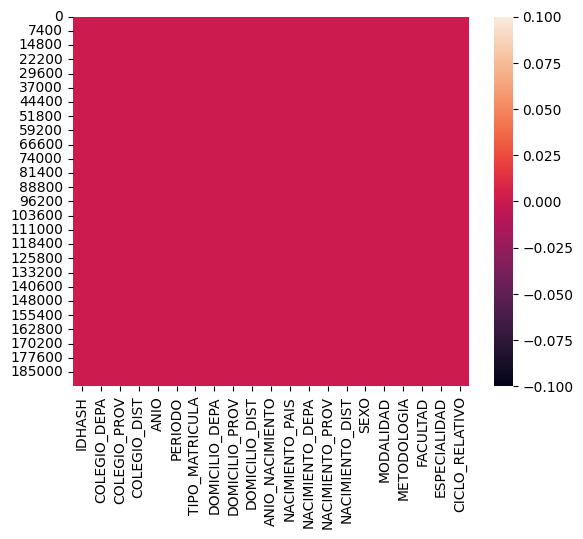

In [ ]:
#verificamos que el dataset haya sido correctamente limpiado
sns.heatmap(entrenamiento.isnull())

In [ ]:
#el color segun lo que investigamos, indica una correlacion fuerte entre los datos

In [ ]:
#ahora si quisieramos preparar el dataset para utilizarlo con un algoritmo como K-Means o DbScan debemos identificar las variables categoricas y aplicarles
#getdummies como se mostro en el laboratorio

#SEXO,MODALIDAD, METODOLOGIA, FACULTAD, ESPECIALIDAD (pueden ser codificadas si hay muchas muestras por categoría), TIPO_MATRICULA

#ELIMINA IDHASH debido a que no servira para nada
entrenamiento.drop(['IDHASH'], axis=1, inplace= True)

<Axes: >

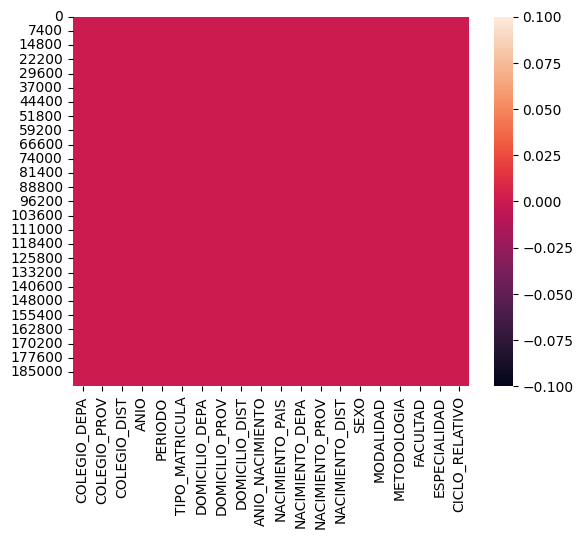

In [ ]:
sns.heatmap(entrenamiento.isnull())

<Axes: >

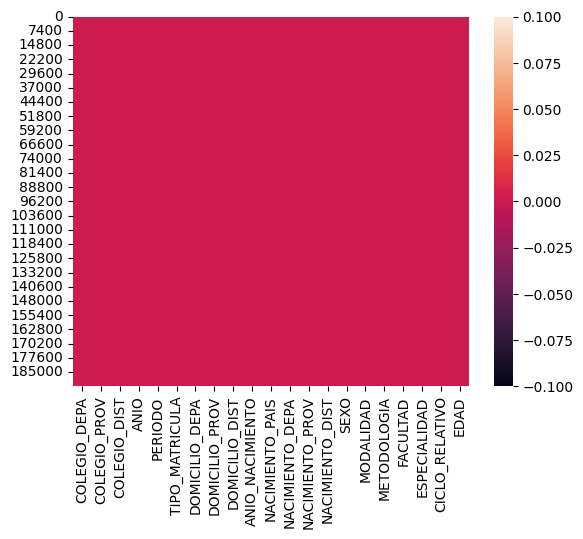

In [ ]:
#inferimos la edad en base al año actual(en el momento) y el año de nacimiento
entrenamiento['EDAD'] = entrenamiento['ANIO'] - entrenamiento['ANIO_NACIMIENTO']
sns.heatmap(entrenamiento.isnull())

In [ ]:
#conteo de las edades
nd = entrenamiento['EDAD'].value_counts().reset_index()
nd.columns = ['NUMERO', 'CANTIDAD']
print(nd)

    NUMERO  CANTIDAD
0       22     24118
1       21     23819
2       23     21690
3       20     21107
4       24     17470
..     ...       ...
60      75         4
61      74         4
62      78         3
63      72         3
64      77         2

[65 rows x 2 columns]


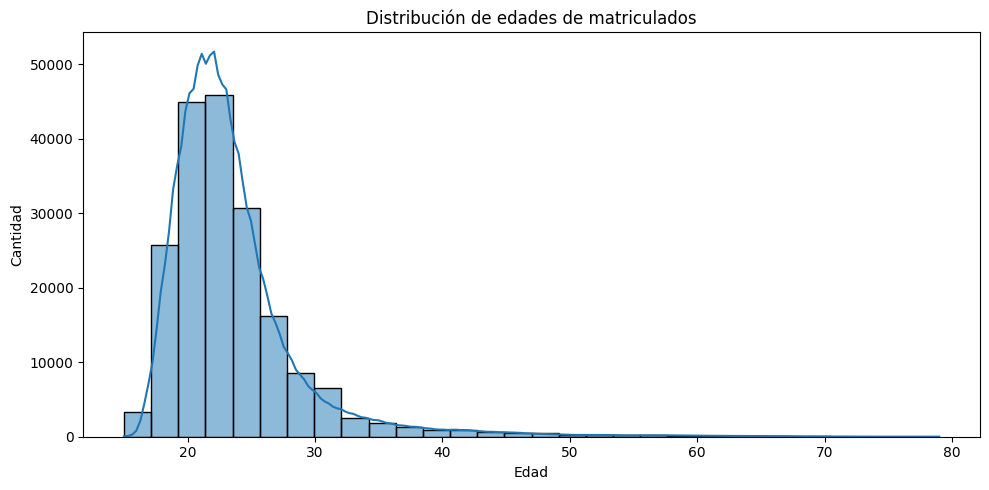

In [ ]:
#una grafica para ver la distribucion de las edades
plt.figure(figsize=(10, 5))
sns.histplot(entrenamiento['EDAD'], bins=30, kde=True)
plt.title('Distribución de edades de matriculados')
plt.xlabel('Edad')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()